In [72]:
import os, shutil, pathlib
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

In [73]:
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=8
)

val_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=8
)

test_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=8
)

Found 118 files belonging to 2 classes.
Found 24 files belonging to 2 classes.
Found 27 files belonging to 2 classes.


In [74]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2)
    ]
)

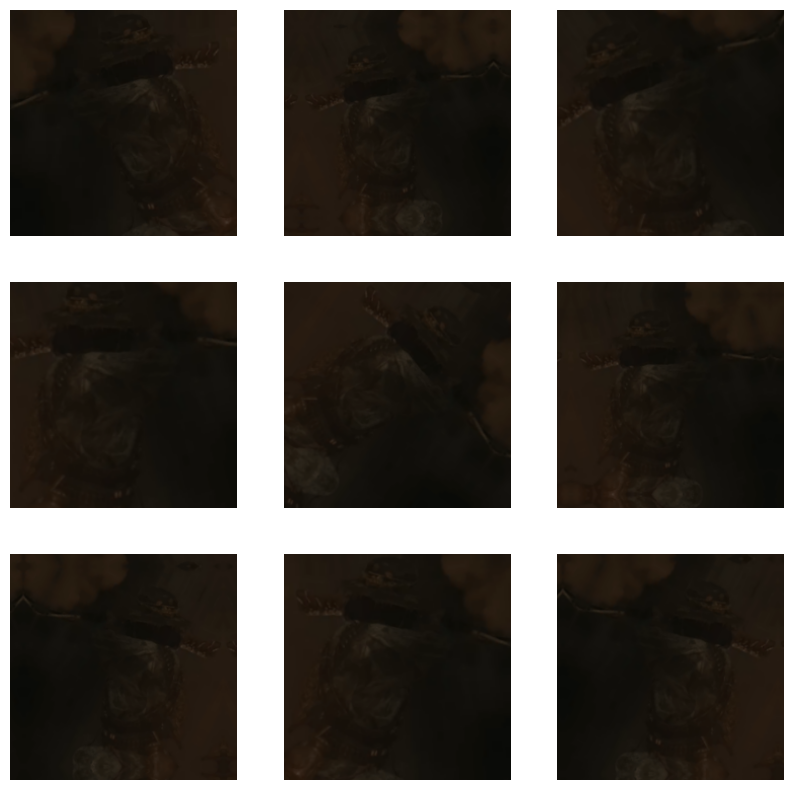

In [75]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [76]:
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1.0/255)(x)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)


model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │        25,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,004,097 (3.83 MB)

 Trainable params: 1,004,097 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [78]:
for data_batch, labels_batch in train_ds:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (8, 224, 224, 3)
labels batch shape: (8,)


In [79]:
callbacks = [keras.callbacks.ModelCheckpoint(
    filepath = "convnet_from_scratch_with_augmentation.keras",
    save_best_only = True,
    monitor = "val_loss")]

In [80]:
history = model.fit(
    train_ds,
    epochs = 15,
    validation_data = val_ds,
    callbacks = callbacks)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 324ms/step - accuracy: 0.5443 - loss: 0.7150 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 536ms/step - accuracy: 0.4369 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 658ms/step - accuracy: 0.5692 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step - accuracy: 0.5608 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 371ms/step - accuracy: 0.4861 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6903
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 300ms/step - accuracy: 0.5559 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.6863
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step - accuracy: 0.5630 - loss: 0.6870 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - accuracy: 0.6402 - loss: 0.6914 - val_accuracy: 0

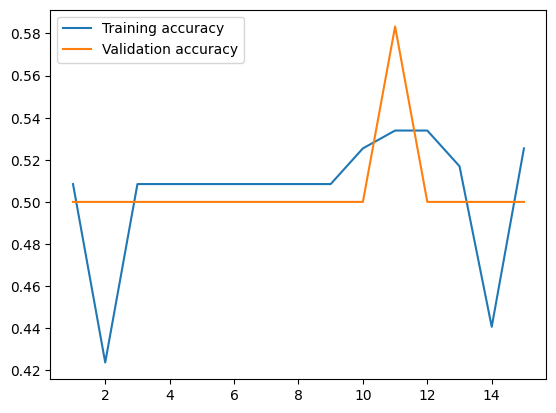

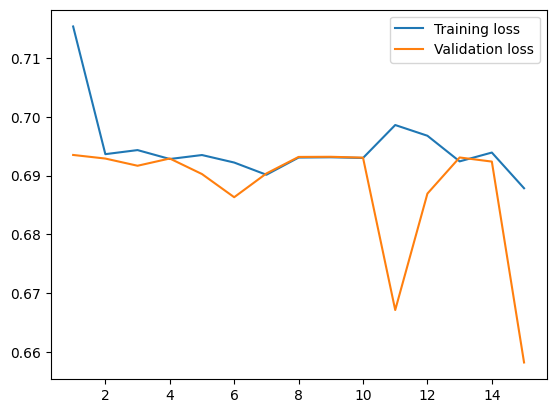

In [81]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [82]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.5282 - loss: 0.6692
Test accuracy: 0.519
